In [142]:
#loading the libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, classification_report

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from scipy import stats
from scipy.stats import zscore
from scipy.stats.mstats import winsorize 

In [2]:
df=pd.read_csv('healthcare-dataset-stroke-data.csv')
df.drop('id',axis=1,inplace=True)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
print(df.info())
print("--------------------")
print("Data shape is ", df.shape)
print("--------------------")
print("Missing values")
print(df.isnull().sum())
print("--------------------")
print("There is ", df.duplicated().sum(), "duplicates")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB
None
--------------------
Data shape is  (5110, 11)
--------------------
Missing values
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married     

In [4]:
df.bmi.mean()

28.893236911794666

In [5]:
df.bmi.median()

28.1

In [6]:
df['bmi'].fillna(df['bmi'].mean(),inplace=True)

In [7]:
df.bmi.isnull().sum()

0

In [8]:
isnull_number=[]
for i in df.columns:
    x=df[i].isnull().sum()
    isnull_number.append(x)
pd.DataFrame(isnull_number,index=df.columns,columns=['Missing Value total'])

,Missing Value total
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [9]:
unique_number=[]
for i in df.columns:
    x=df[i].value_counts().count()
    unique_number.append(x)
pd.DataFrame(unique_number,index=df.columns,columns=["Unique Number Total"])

,Unique Number Total
gender,3
age,104
hypertension,2
heart_disease,2
ever_married,2
work_type,5
Residence_type,2
avg_glucose_level,3979
bmi,419
smoking_status,4


In [10]:
#converting age to int
df.age=df.age.astype('int64')
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,Male,80,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,Male,51,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


In [11]:
categorical_columns=['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
                            'Residence_type', 'smoking_status', 'stroke']
numerical_colums=['age', 'avg_glucose_level', 'bmi']

In [12]:
categorical_axis = ['name of gender', 'hypertensive','heart_disease', 'married', 'place of work', 'type of residence', 'smokes']
numerical_axis=['age of individual', 'glucose_level', 'body_mass_index']

In [13]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,43.215264,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.633866,0.296607,0.226063,45.283560,7.698018,0.215320
min,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.400000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## VISUALIZATION

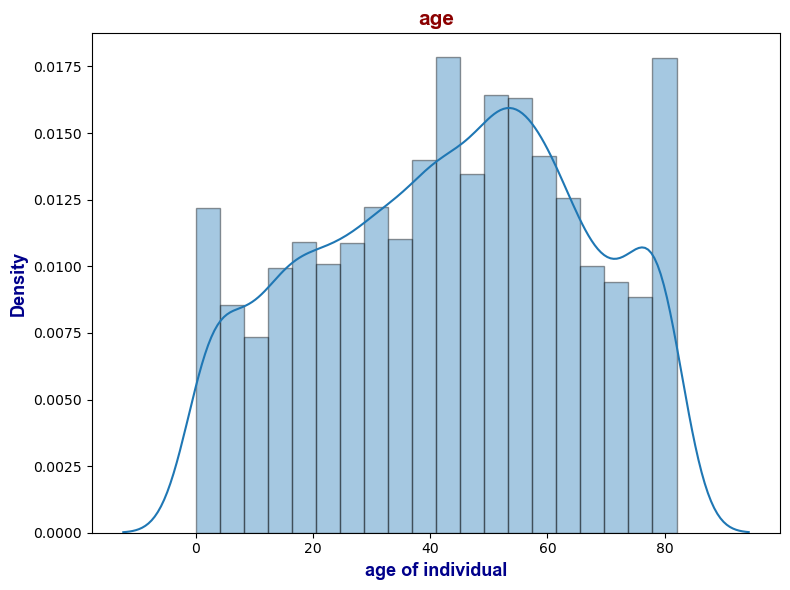

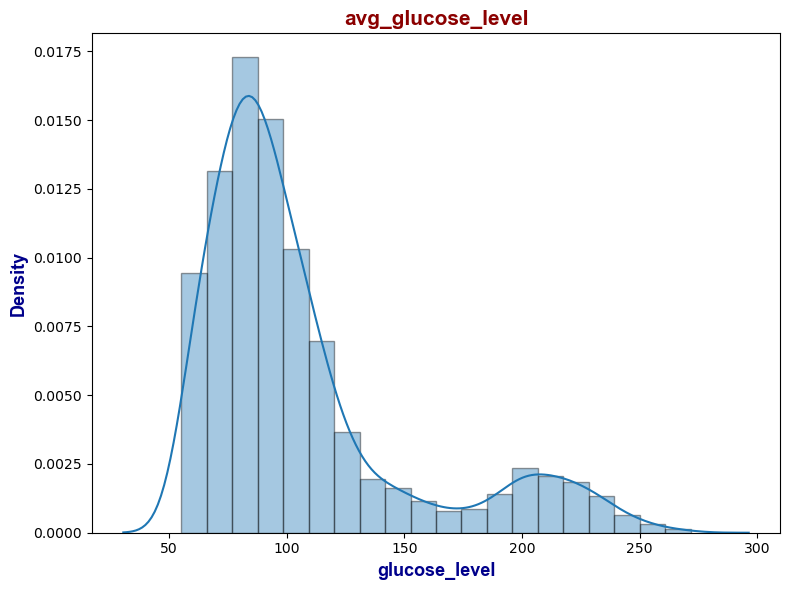

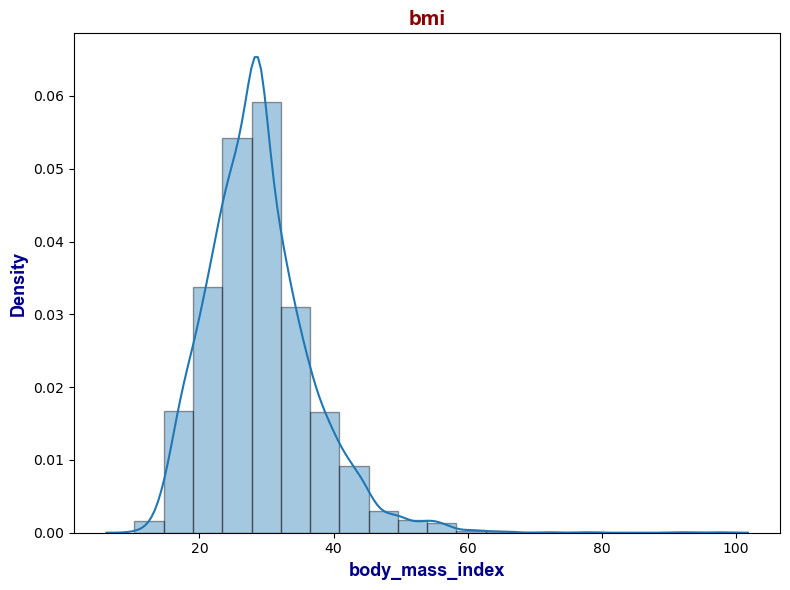

In [14]:
title_font={'family': 'arial', 'color': 'darkred', 'weight': 'bold', 'size': 15}
axis_font={'family': 'arial', 'color': 'darkblue', 'weight': 'bold', 'size': 13}

for i,z in list(zip(numerical_colums, numerical_axis)):
    plt.figure(figsize=(8,6))
    sns.distplot(df[i],hist_kws=dict(linewidth=1,edgecolor='k'),bins=20)
    plt.title(i,fontdict=title_font)
    plt.xlabel(z,fontdict=axis_font)
    plt.ylabel('Density',fontdict=axis_font)
    plt.tight_layout()
    plt.show()
    
    

**there is a significant skew**

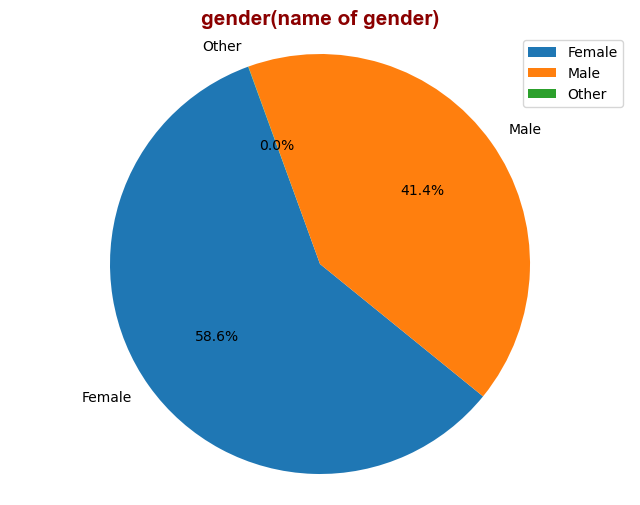

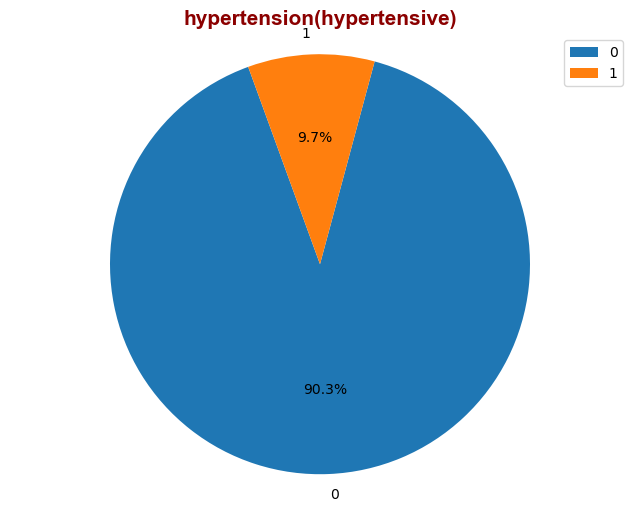

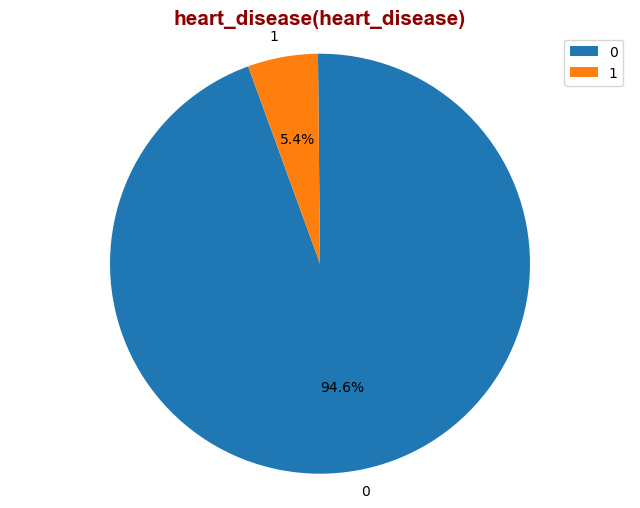

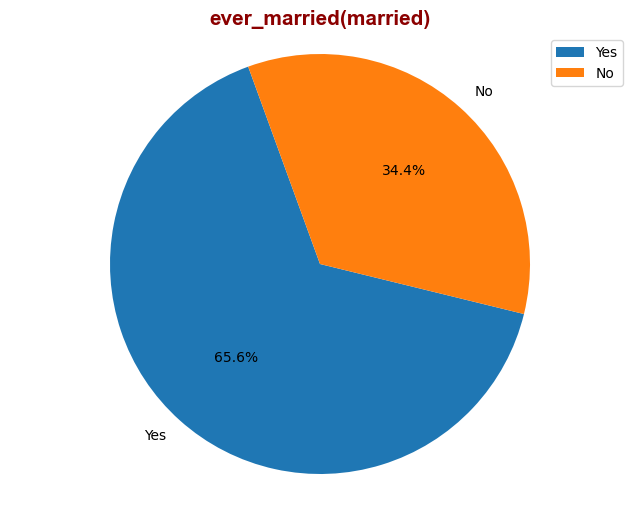

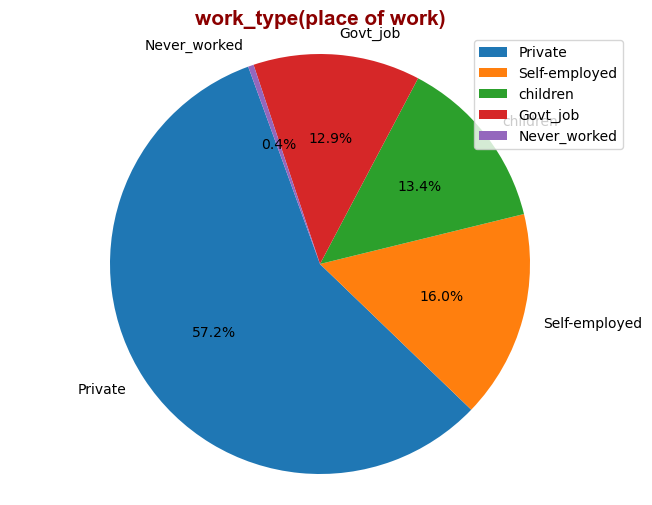

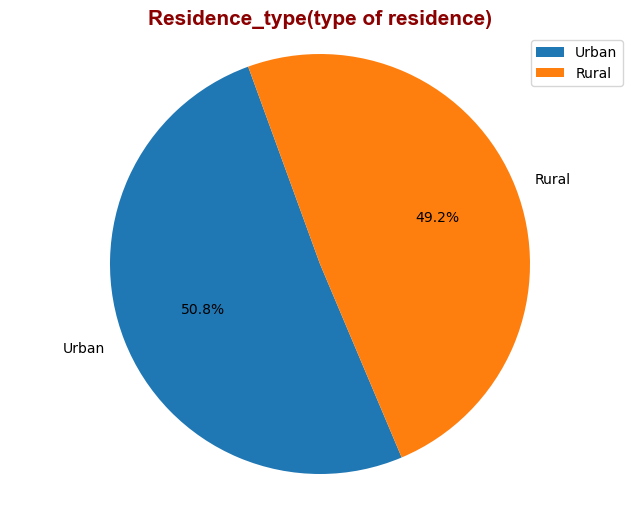

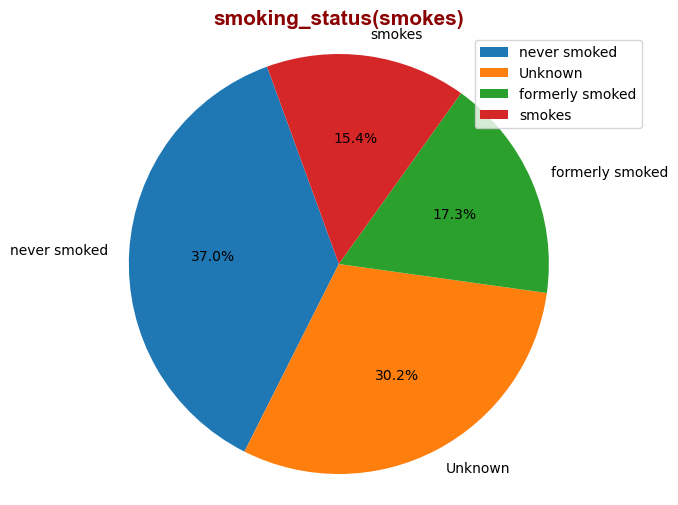

In [15]:
title_font={'family': 'arial', 'color': 'darkred', 'weight': 'bold', 'size': 15}
axis_font={'family': 'arial', 'color': 'darkblue', 'weight': 'bold', 'size': 13}

for i, z in list(zip(categorical_columns,categorical_axis)):
    fig,ax = plt.subplots(figsize=(8,6))
    
    observation_values=list(df[i].value_counts().index)
    total_observation = list(df[i].value_counts())
    
    ax.pie(total_observation,labels=observation_values, autopct='%1.1f%%',startangle=110, labeldistance=1.1)
    ax.axis('equal')
    
    plt.title((i +'('+ z+ ')'), fontdict=title_font)
    plt.legend()
    plt.show()

In [16]:
#gender kinda have a feature of other, of 0% which is insignificant
df=df[df['gender']!='Other']
x=df.gender.value_counts()
print(x)

gender
Female    2994
Male      2115
Name: count, dtype: int64


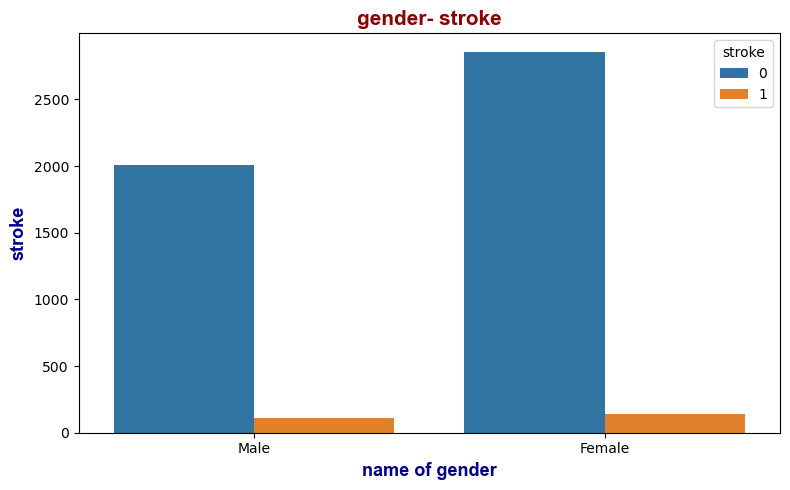

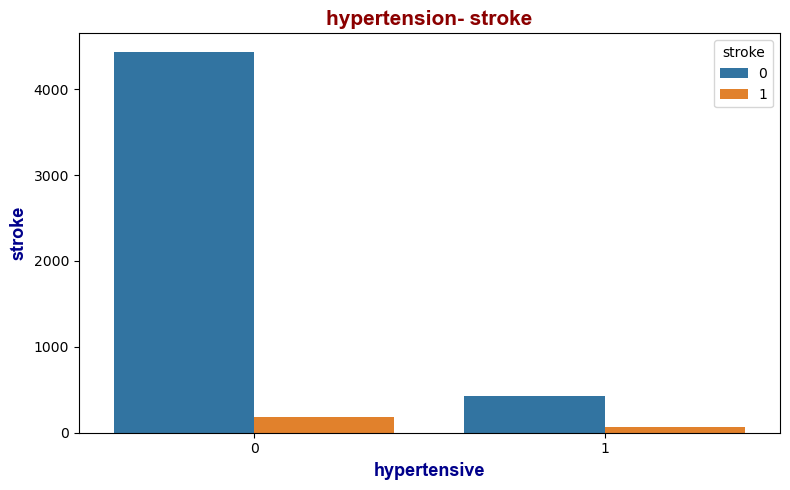

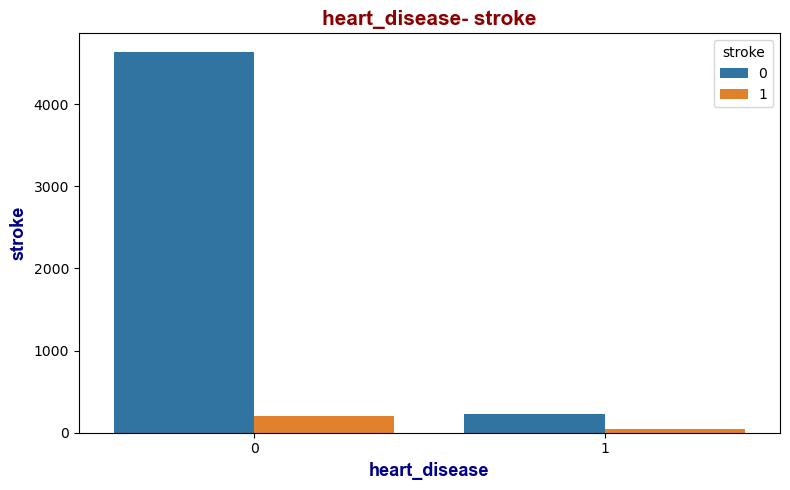

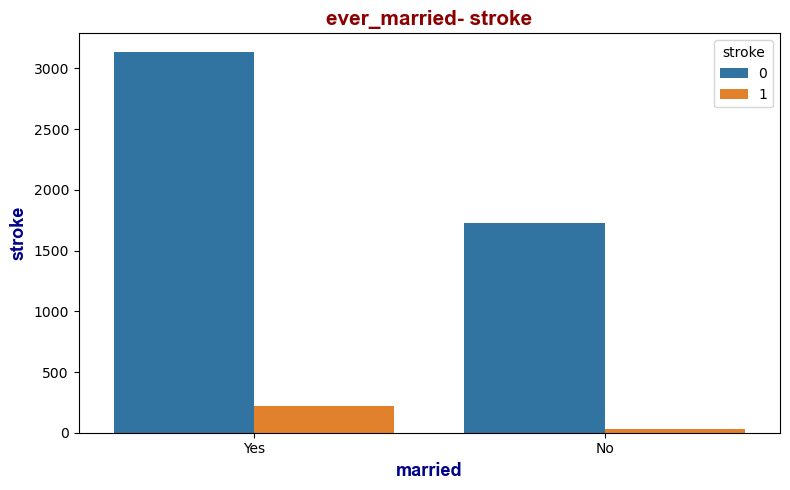

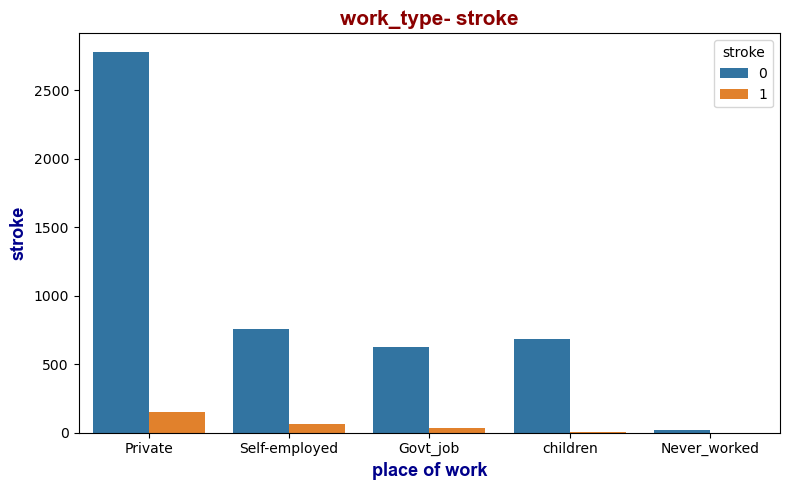

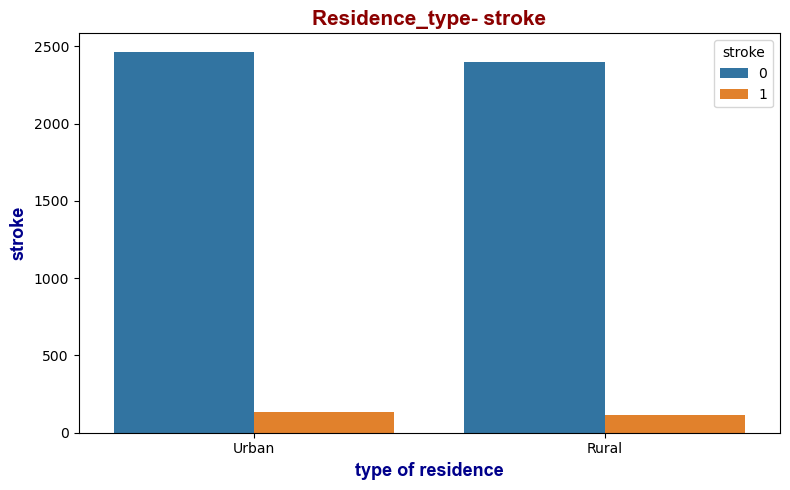

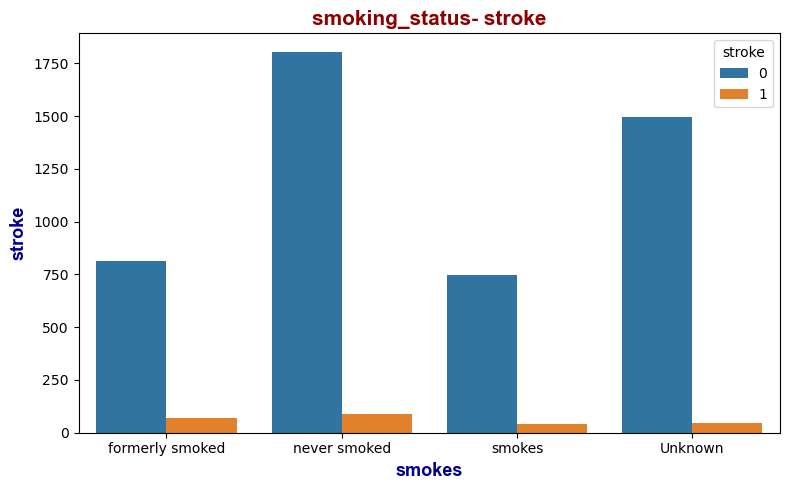

In [17]:
title_font={'family': 'arial', 'color': 'darkred', 'weight': 'bold', 'size': 15}
axis_font={'family': 'arial', 'color': 'darkblue', 'weight': 'bold', 'size': 13}

for i, z in list(zip(categorical_columns,categorical_axis)):
    plt.figure(figsize=(8,5))
    sns.countplot( x=i, data=df[categorical_columns], hue='stroke')
    
    plt.title(i+ '- stroke',fontdict=title_font)
    plt.xlabel(z,fontdict=axis_font)
    plt.ylabel('stroke',fontdict=axis_font)
    
    plt.tight_layout()
    plt.show()
    
    

**Gender vs Stroke** 
- the graph shows that the female happen to experience stroke more than the men
- thhose in orivate sector are likely to express stroke more than those working in the other sectors
- there isnt much diff btw who is likely to have stroke in urban and rurual area
- and wow, those who never smoked happen to have stroke more than those who smokes, probably there are outliners in this data we have to take a lot at.

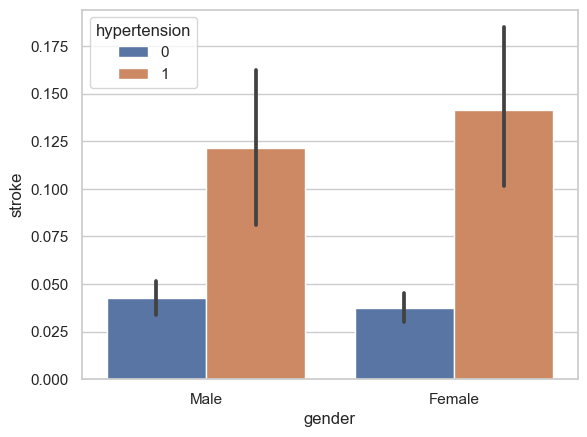

In [18]:
sns.set(style='whitegrid')
sns.barplot(x='gender', y='stroke', hue='hypertension', data=df);

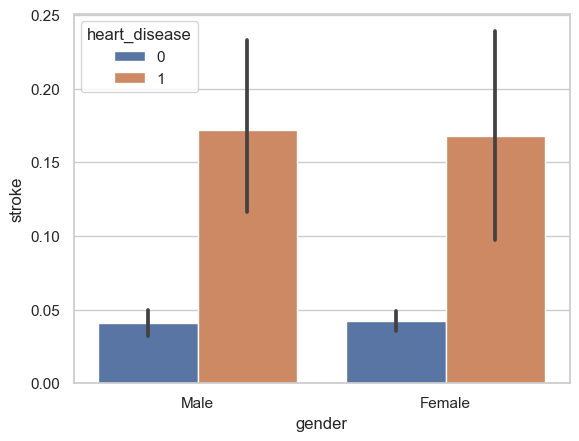

In [19]:
sns.set(style='whitegrid')
sns.barplot(x='gender', y='stroke', hue='heart_disease', data=df);

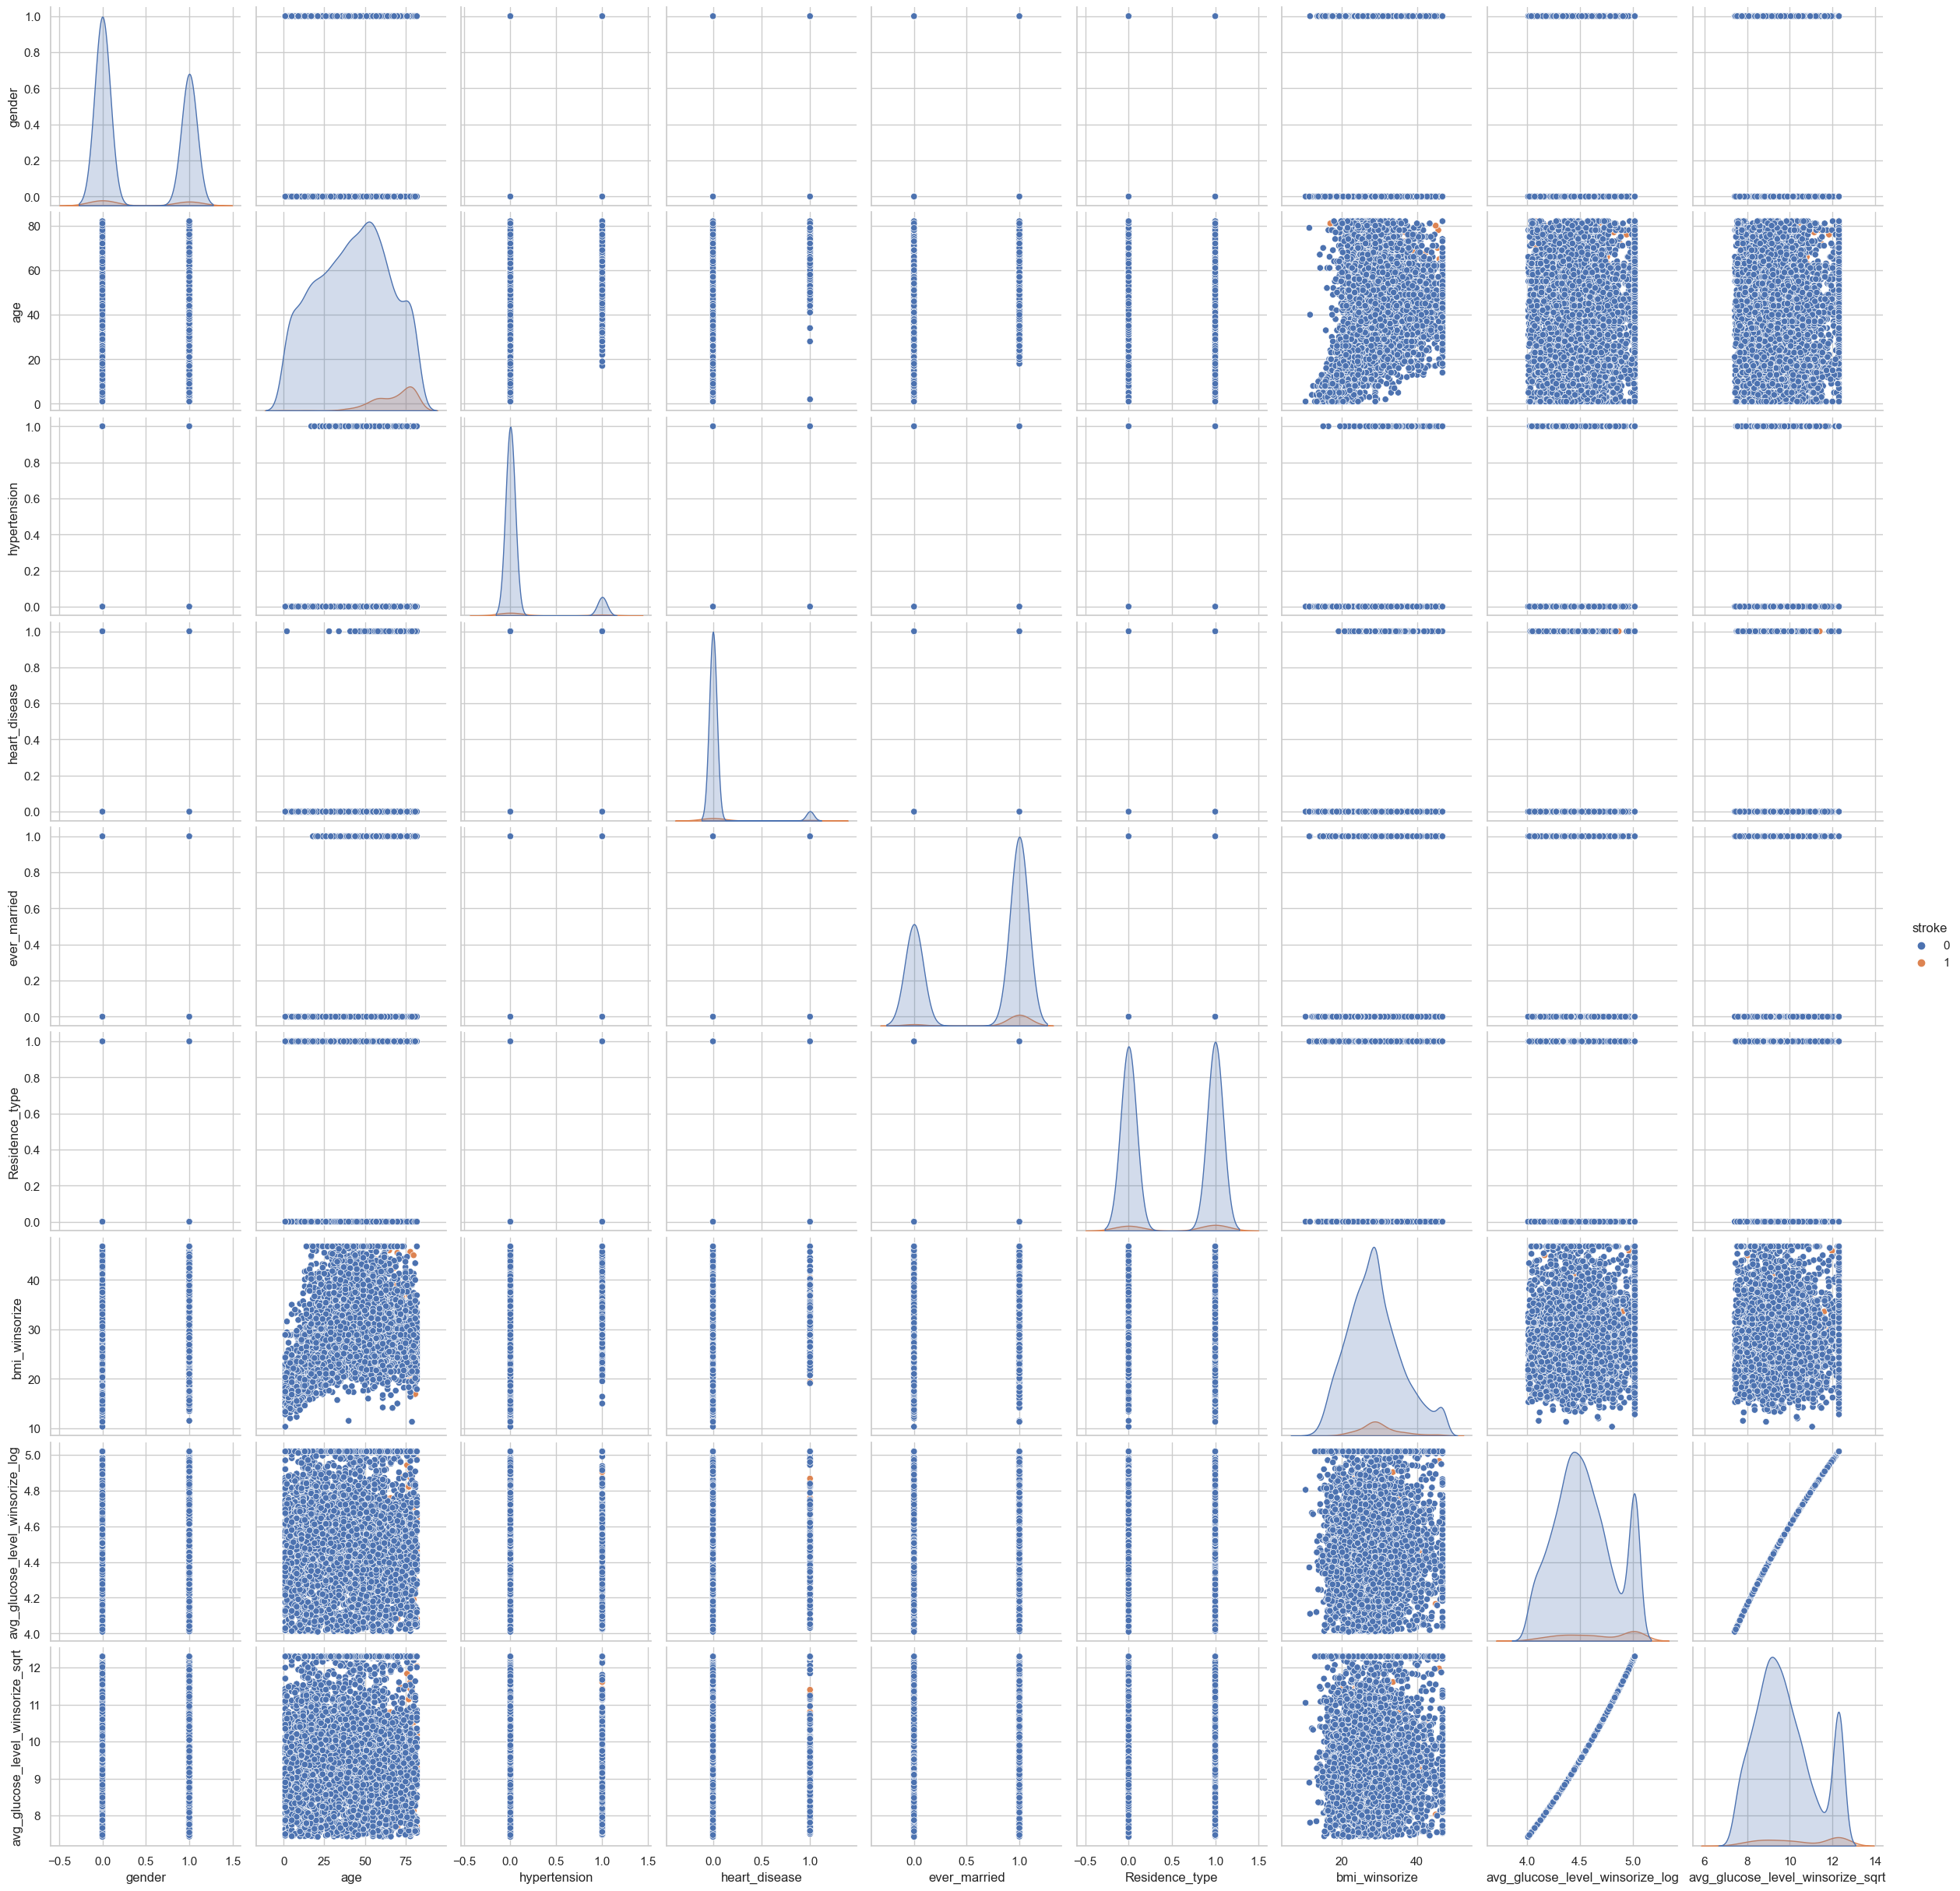

In [82]:
sns.pairplot(df,hue='stroke',height=2.75)
plt.show()

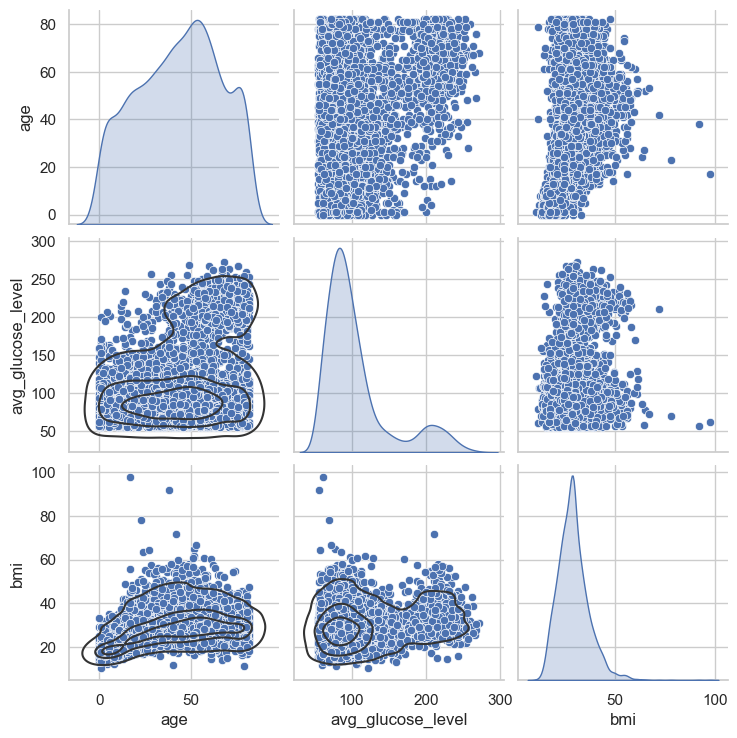

In [20]:
graph=sns.pairplot(df[numerical_colums],diag_kind='kde')
graph.map_lower(sns.kdeplot,levels=4, color='.2')
plt.show()

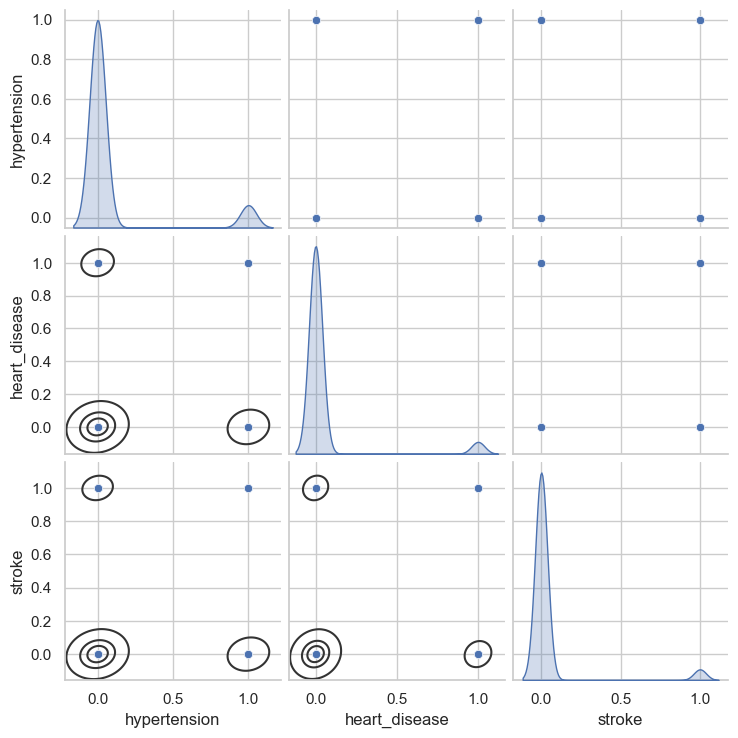

In [21]:
graph=sns.pairplot(df[categorical_columns],diag_kind='kde')
graph.map_lower(sns.kdeplot,levels=4, color='.2')
plt.show()

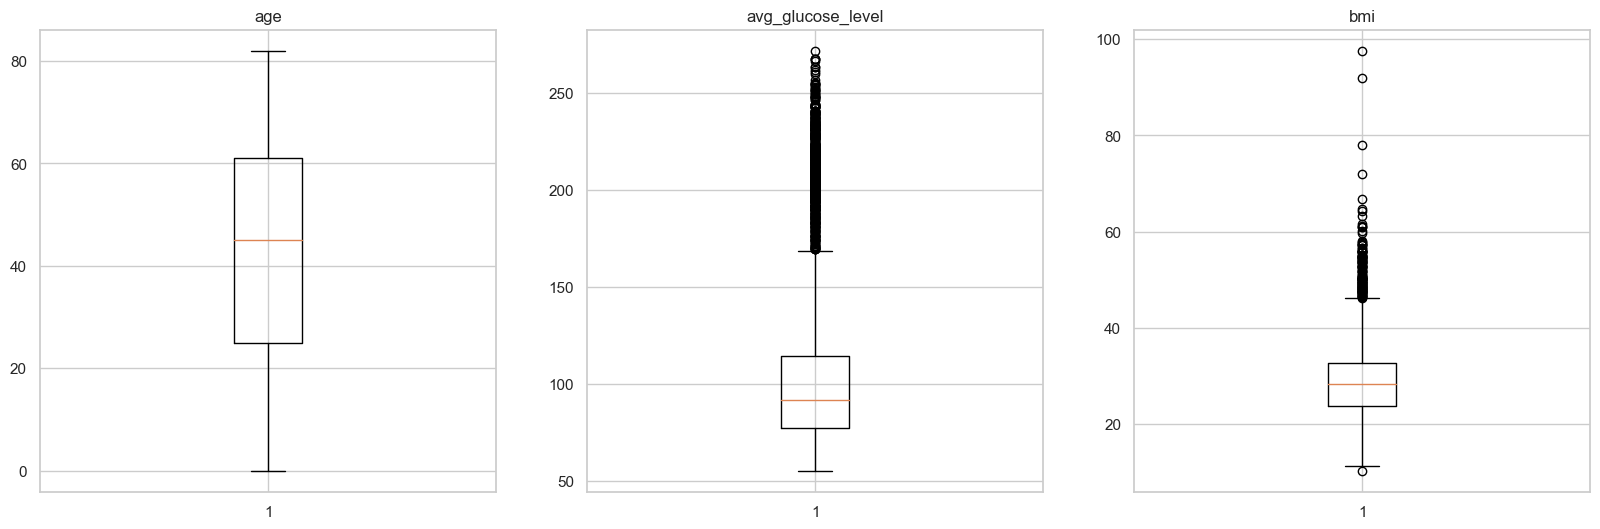

In [22]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(20,6))

ax1.boxplot(df['age'])
ax1.set_title('age')

ax2.boxplot(df['avg_glucose_level'])
ax2.set_title('avg_glucose_level')

ax3.boxplot(df['bmi'])
ax3.set_title('bmi')


plt.show()

plt.figure(figsize=(12, 6))


for i, numeric in enumerate(numerical_colums, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[numeric], color='purple')
    plt.title(f'Box Plot of {numerical_colums}')
    plt.ylabel(numerical_colums)
plt.tight_layout();


In [23]:
zscore_avg_glucose_level = zscore(df['avg_glucose_level'])
for threshold in range(1,4): 
    print('Threshold Value: {}' .format(threshold))
    print('Number of Outliers: {}'.format(len(np.where(zscore_avg_glucose_level>threshold)[0])))
    print('--------------')


Threshold Value: 1
Number of Outliers: 718
--------------
Threshold Value: 2
Number of Outliers: 471
--------------
Threshold Value: 3
Number of Outliers: 49
--------------


In [24]:
df[zscore_avg_glucose_level>1][['avg_glucose_level']]

,avg_glucose_level
0,228.69
1,202.21
3,171.23
4,174.12
5,186.21
...,...
5063,179.38
5064,193.88
5076,174.37
5086,152.56


In [25]:
df[zscore_avg_glucose_level>1].avg_glucose_level.min()

151.56

In [26]:
df[df['avg_glucose_level']<151.56].avg_glucose_level.max()

151.33

In [27]:
winsorize_percentile_avg_glucose_level=stats.percentileofscore(df['avg_glucose_level'],151.33)/100
print(winsorize_percentile_avg_glucose_level)

0.8594636915247602


In [28]:
1-winsorize_percentile_avg_glucose_level

0.1405363084752398

In [29]:
avg_glucose_level_winsorize=winsorize(df.avg_glucose_level,(0, (1-winsorize_percentile_avg_glucose_level)))

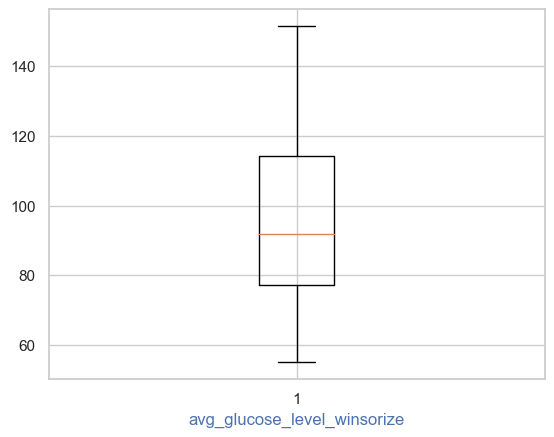

In [30]:
plt.boxplot(avg_glucose_level_winsorize)
plt.xlabel('avg_glucose_level_winsorize',color='b')
plt.show()

In [31]:
df['avg_glucose_level_winsorize']=avg_glucose_level_winsorize

In [32]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,avg_glucose_level_winsorize
0,Male,67,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1,151.33
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1,151.33
2,Male,80,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1,105.92
3,Female,49,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1,151.33
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1,151.33
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0,83.75
5106,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0,125.20
5107,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0,82.99
5108,Male,51,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0,151.33


In [33]:
def iqr(df,var):
    q1=np.quantile(df[var], 0.25)
    q3=np.quantile(df[var],0.75)
    diff=q3-q1
    lower_v=q1-(1.5*diff)
    upper_v=q3+(1.5*diff)
    return df[(df[var]<lower_v) | (df[var]>upper_v)]

In [34]:
bmi_out=iqr(df,'bmi')
bmi_out

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,avg_glucose_level_winsorize
21,Female,52,1,0,Yes,Self-employed,Urban,233.29,48.9,never smoked,1,151.33
66,Female,70,0,0,Yes,Private,Urban,221.58,47.5,never smoked,1,151.33
113,Female,45,0,0,Yes,Private,Rural,224.10,56.6,never smoked,1,151.33
254,Female,47,0,0,Yes,Private,Urban,210.95,50.1,Unknown,0,151.33
258,Female,74,1,0,Yes,Self-employed,Urban,205.84,54.6,never smoked,0,151.33
...,...,...,...,...,...,...,...,...,...,...,...,...
4906,Female,53,0,0,Yes,Private,Urban,70.51,54.1,never smoked,0,70.51
4952,Male,51,1,0,Yes,Self-employed,Rural,211.83,56.6,never smoked,0,151.33
5009,Female,50,0,0,Yes,Self-employed,Rural,126.85,49.5,formerly smoked,0,126.85
5057,Female,49,0,0,Yes,Govt_job,Urban,69.92,47.6,never smoked,0,69.92


In [35]:
df[df['bmi']<46.9].bmi.max()

46.8

In [36]:
winsorize_percentile_bmi=stats.percentileofscore(df['bmi'], 46.8)/100
print(winsorize_percentile_bmi)

0.9767077706009003


In [37]:
1-winsorize_percentile_bmi

0.023292229399099695

In [38]:
bmi_winsorize=winsorize(df.bmi, (0, (1-winsorize_percentile_bmi)))
bmi_winsorize

masked_array(data=[36.6       , 28.89323691, 32.5       , ...,
                   30.6       , 25.6       , 26.2       ],
             mask=False,
       fill_value=1e+20)

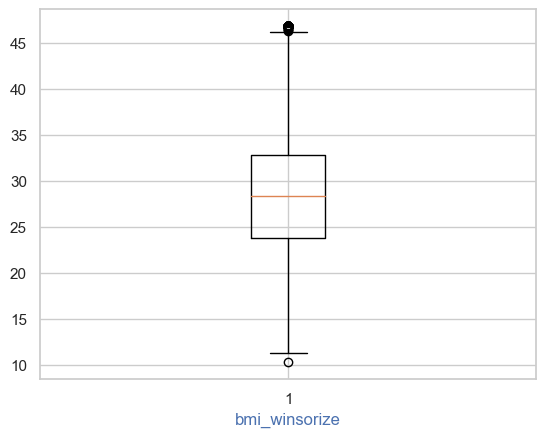

In [39]:
plt.boxplot(bmi_winsorize)
plt.xlabel('bmi_winsorize', color='b')
plt.show()

In [40]:
df['bmi_winsorize']=bmi_winsorize

In [41]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,avg_glucose_level_winsorize,bmi_winsorize
0,Male,67,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1,151.33,36.600000
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1,151.33,28.893237
2,Male,80,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1,105.92,32.500000
3,Female,49,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1,151.33,34.400000
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1,151.33,24.000000


In [42]:
df.drop(['bmi','avg_glucose_level'], axis=1, inplace=True)

In [43]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke,avg_glucose_level_winsorize,bmi_winsorize
0,Male,67,0,1,Yes,Private,Urban,formerly smoked,1,151.33,36.600000
1,Female,61,0,0,Yes,Self-employed,Rural,never smoked,1,151.33,28.893237
2,Male,80,0,1,Yes,Private,Rural,never smoked,1,105.92,32.500000
3,Female,49,0,0,Yes,Private,Urban,smokes,1,151.33,34.400000
4,Female,79,1,0,Yes,Self-employed,Rural,never smoked,1,151.33,24.000000
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80,1,0,Yes,Private,Urban,never smoked,0,83.75,28.893237
5106,Female,81,0,0,Yes,Self-employed,Urban,never smoked,0,125.20,40.000000
5107,Female,35,0,0,Yes,Self-employed,Rural,never smoked,0,82.99,30.600000
5108,Male,51,0,0,Yes,Private,Rural,formerly smoked,0,151.33,25.600000


In [44]:
df.describe()

,age,hypertension,heart_disease,stroke,avg_glucose_level_winsorize,bmi_winsorize
count,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000
mean,43.218634,0.097475,0.054022,0.048738,98.627504,28.734751
std,22.634799,0.296633,0.226084,0.215340,28.605279,7.149815
min,0.000000,0.000000,0.000000,0.000000,55.120000,10.300000
25%,25.000000,0.000000,0.000000,0.000000,77.240000,23.800000
50%,45.000000,0.000000,0.000000,0.000000,91.880000,28.400000
75%,61.000000,0.000000,0.000000,0.000000,114.090000,32.800000
max,82.000000,1.000000,1.000000,1.000000,151.330000,46.800000


In [45]:
df.shape

(5109, 11)

In [46]:
df = df[df['age'] != 0.000000]
print(df.shape)

(5066, 11)


In [47]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke,avg_glucose_level_winsorize,bmi_winsorize
0,Male,67,0,1,Yes,Private,Urban,formerly smoked,1,151.33,36.600000
1,Female,61,0,0,Yes,Self-employed,Rural,never smoked,1,151.33,28.893237
2,Male,80,0,1,Yes,Private,Rural,never smoked,1,105.92,32.500000
3,Female,49,0,0,Yes,Private,Urban,smokes,1,151.33,34.400000
4,Female,79,1,0,Yes,Self-employed,Rural,never smoked,1,151.33,24.000000


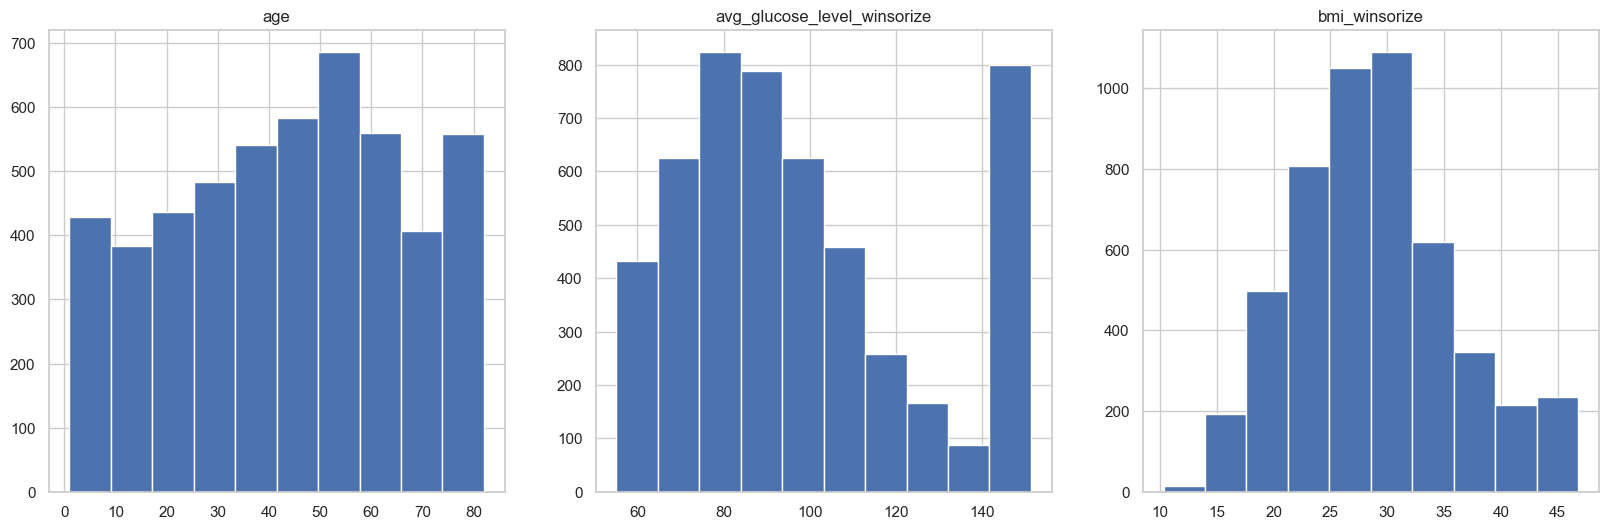

In [48]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(20,6))

ax1.hist(df['age'])
ax1.set_title('age')

ax2.hist(df['avg_glucose_level_winsorize'])
ax2.set_title('avg_glucose_level_winsorize')

ax3.hist(df['bmi_winsorize'])
ax3.set_title('bmi_winsorize')


plt.show()

In [49]:
df[['age','avg_glucose_level_winsorize','bmi_winsorize']].agg(['skew']).transpose()

,skew
age,-0.134984
avg_glucose_level_winsorize,0.647605
bmi_winsorize,0.466659


In [50]:
#avg_glucose have an unsymmetrical data, i take the log and sqrt of the column
df['avg_glucose_level_winsorize_log']=np.log(df['avg_glucose_level_winsorize'])
df['avg_glucose_level_winsorize_sqrt']=np.sqrt(df['avg_glucose_level_winsorize'])

In [51]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke,avg_glucose_level_winsorize,bmi_winsorize,avg_glucose_level_winsorize_log,avg_glucose_level_winsorize_sqrt
0,Male,67,0,1,Yes,Private,Urban,formerly smoked,1,151.33,36.600000,5.019463,12.301626
1,Female,61,0,0,Yes,Self-employed,Rural,never smoked,1,151.33,28.893237,5.019463,12.301626
2,Male,80,0,1,Yes,Private,Rural,never smoked,1,105.92,32.500000,4.662684,10.291744
3,Female,49,0,0,Yes,Private,Urban,smokes,1,151.33,34.400000,5.019463,12.301626
4,Female,79,1,0,Yes,Self-employed,Rural,never smoked,1,151.33,24.000000,5.019463,12.301626


In [52]:
df[['avg_glucose_level_winsorize', 'avg_glucose_level_winsorize_log', 'avg_glucose_level_winsorize_sqrt']].agg(['skew']).transpose()

,skew
avg_glucose_level_winsorize,0.647605
avg_glucose_level_winsorize_log,0.224666
avg_glucose_level_winsorize_sqrt,0.445937


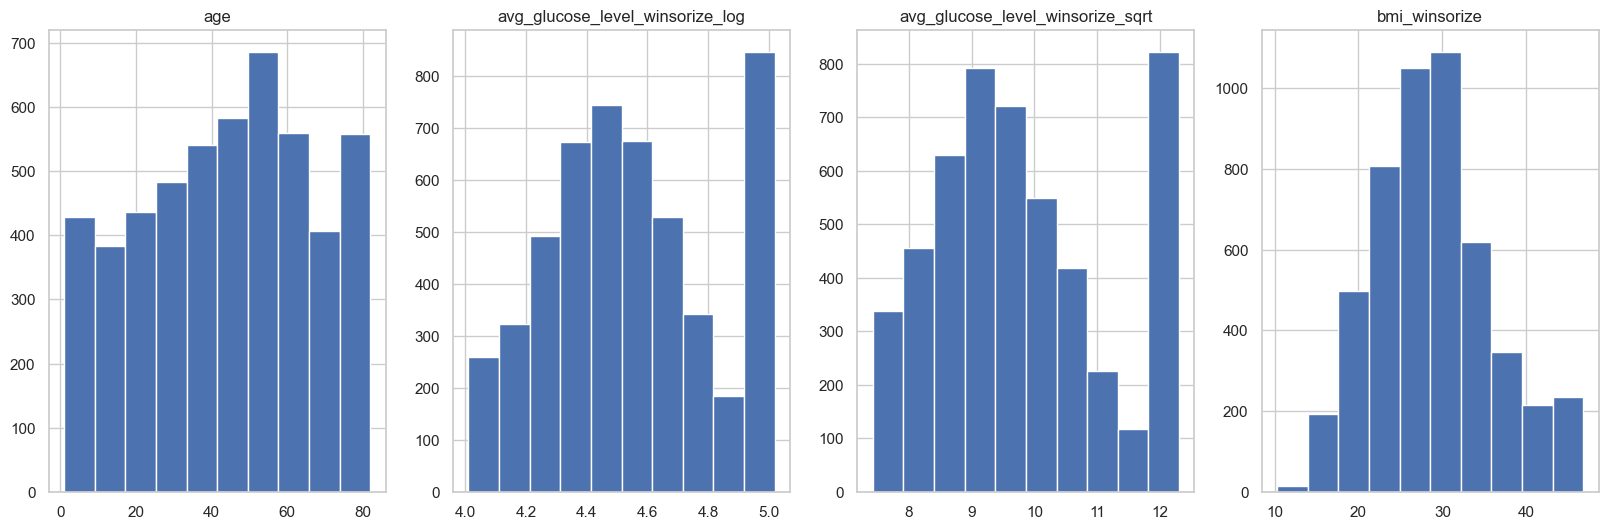

In [53]:
fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,4, figsize=(20,6))

ax1.hist(df['age'])
ax1.set_title('age')

ax2.hist(df['avg_glucose_level_winsorize_log'])
ax2.set_title('avg_glucose_level_winsorize_log')

ax3.hist(df['avg_glucose_level_winsorize_sqrt'])
ax3.set_title('avg_glucose_level_winsorize_sqrt')

ax4.hist(df['bmi_winsorize'])
ax4.set_title('bmi_winsorize')


plt.show()

**i have accomplished by eliminating the skewness of the data, and evidently from the graph, they are all distributed**

In [54]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke,avg_glucose_level_winsorize,bmi_winsorize,avg_glucose_level_winsorize_log,avg_glucose_level_winsorize_sqrt
0,Male,67,0,1,Yes,Private,Urban,formerly smoked,1,151.33,36.600000,5.019463,12.301626
1,Female,61,0,0,Yes,Self-employed,Rural,never smoked,1,151.33,28.893237,5.019463,12.301626
2,Male,80,0,1,Yes,Private,Rural,never smoked,1,105.92,32.500000,4.662684,10.291744
3,Female,49,0,0,Yes,Private,Urban,smokes,1,151.33,34.400000,5.019463,12.301626
4,Female,79,1,0,Yes,Self-employed,Rural,never smoked,1,151.33,24.000000,5.019463,12.301626


In [55]:
df.drop(['avg_glucose_level_winsorize'],axis=1,inplace=True)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke,bmi_winsorize,avg_glucose_level_winsorize_log,avg_glucose_level_winsorize_sqrt
0,Male,67,0,1,Yes,Private,Urban,formerly smoked,1,36.600000,5.019463,12.301626
1,Female,61,0,0,Yes,Self-employed,Rural,never smoked,1,28.893237,5.019463,12.301626
2,Male,80,0,1,Yes,Private,Rural,never smoked,1,32.500000,4.662684,10.291744
3,Female,49,0,0,Yes,Private,Urban,smokes,1,34.400000,5.019463,12.301626
4,Female,79,1,0,Yes,Self-employed,Rural,never smoked,1,24.000000,5.019463,12.301626


### LabelEncoder
- since the categorical features(**gender, ever_married, Residence_type**) are in orderly form, i employ the use of LabelEncoder 

In [61]:
unique_number=[]
for i in df.columns:
    x=df[i].value_counts().count()
    unique_number.append(x)
pd.DataFrame(unique_number,index=df.columns,columns=["Unique Number Total"])

,Unique Number Total
gender,2
age,82
hypertension,2
heart_disease,2
ever_married,2
work_type,5
Residence_type,2
smoking_status,4
stroke,2
bmi_winsorize,338


In [56]:
LabelEncoder = LabelEncoder()
df['gender'] = LabelEncoder.fit_transform(df['gender'])
df['ever_married'] = LabelEncoder.fit_transform(df['ever_married'])
df['Residence_type'] = LabelEncoder.fit_transform(df['Residence_type'])

In [57]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke,bmi_winsorize,avg_glucose_level_winsorize_log,avg_glucose_level_winsorize_sqrt
0,1,67,0,1,1,Private,1,formerly smoked,1,36.600000,5.019463,12.301626
1,0,61,0,0,1,Self-employed,0,never smoked,1,28.893237,5.019463,12.301626
2,1,80,0,1,1,Private,0,never smoked,1,32.500000,4.662684,10.291744
3,0,49,0,0,1,Private,1,smokes,1,34.400000,5.019463,12.301626
4,0,79,1,0,1,Self-employed,0,never smoked,1,24.000000,5.019463,12.301626


### OneHotEncoder
- columns such as (**work_type, smoking_status**) will need OneHotEncoder 

In [58]:
df_copy=df.copy()
df_copy.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke,bmi_winsorize,avg_glucose_level_winsorize_log,avg_glucose_level_winsorize_sqrt
0,1,67,0,1,1,Private,1,formerly smoked,1,36.600000,5.019463,12.301626
1,0,61,0,0,1,Self-employed,0,never smoked,1,28.893237,5.019463,12.301626
2,1,80,0,1,1,Private,0,never smoked,1,32.500000,4.662684,10.291744
3,0,49,0,0,1,Private,1,smokes,1,34.400000,5.019463,12.301626
4,0,79,1,0,1,Self-employed,0,never smoked,1,24.000000,5.019463,12.301626


In [59]:
categorical2=['work_type', 'smoking_status']
df_copy = pd.get_dummies(df_copy, columns=categorical2, drop_first=True).astype('int64')
df_copy.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,stroke,bmi_winsorize,avg_glucose_level_winsorize_log,avg_glucose_level_winsorize_sqrt,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67,0,1,1,1,1,36,5,12,0,1,0,0,1,0,0
1,0,61,0,0,1,0,1,28,5,12,0,0,1,0,0,1,0
2,1,80,0,1,1,0,1,32,4,10,0,1,0,0,0,1,0
3,0,49,0,0,1,1,1,34,5,12,0,1,0,0,0,0,1
4,0,79,1,0,1,0,1,24,5,12,0,0,1,0,0,1,0


### RobustScaler
- **age, bmi_winsorize,avg_glucose_level_winsorize_log, avg_glucose_level_winsorize_sqrt**

- i took this approach because the columns to be scaled were having outliers

In [60]:
new_numerical_cols = ['age', 'bmi_winsorize', 'avg_glucose_level_winsorize_log', 'avg_glucose_level_winsorize_sqrt']
robust_scaler = RobustScaler()
df_copy[new_numerical_cols] = robust_scaler.fit_transform(df_copy[new_numerical_cols])
df_copy.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,stroke,bmi_winsorize,avg_glucose_level_winsorize_log,avg_glucose_level_winsorize_sqrt,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,0.628571,0,1,1,1,1,0.888889,1.0,1.5,0,1,0,0,1,0,0
1,0,0.457143,0,0,1,0,1,0.000000,1.0,1.5,0,0,1,0,0,1,0
2,1,1.000000,0,1,1,0,1,0.444444,0.0,0.5,0,1,0,0,0,1,0
3,0,0.114286,0,0,1,1,1,0.666667,1.0,1.5,0,1,0,0,0,0,1
4,0,0.971429,1,0,1,0,1,-0.444444,1.0,1.5,0,0,1,0,0,1,0


In [64]:
df_copy.count()

gender                              5066
age                                 5066
hypertension                        5066
heart_disease                       5066
ever_married                        5066
Residence_type                      5066
stroke                              5066
bmi_winsorize                       5066
avg_glucose_level_winsorize_log     5066
avg_glucose_level_winsorize_sqrt    5066
work_type_Never_worked              5066
work_type_Private                   5066
work_type_Self-employed             5066
work_type_children                  5066
smoking_status_formerly smoked      5066
smoking_status_never smoked         5066
smoking_status_smokes               5066
dtype: int64

<Axes: >

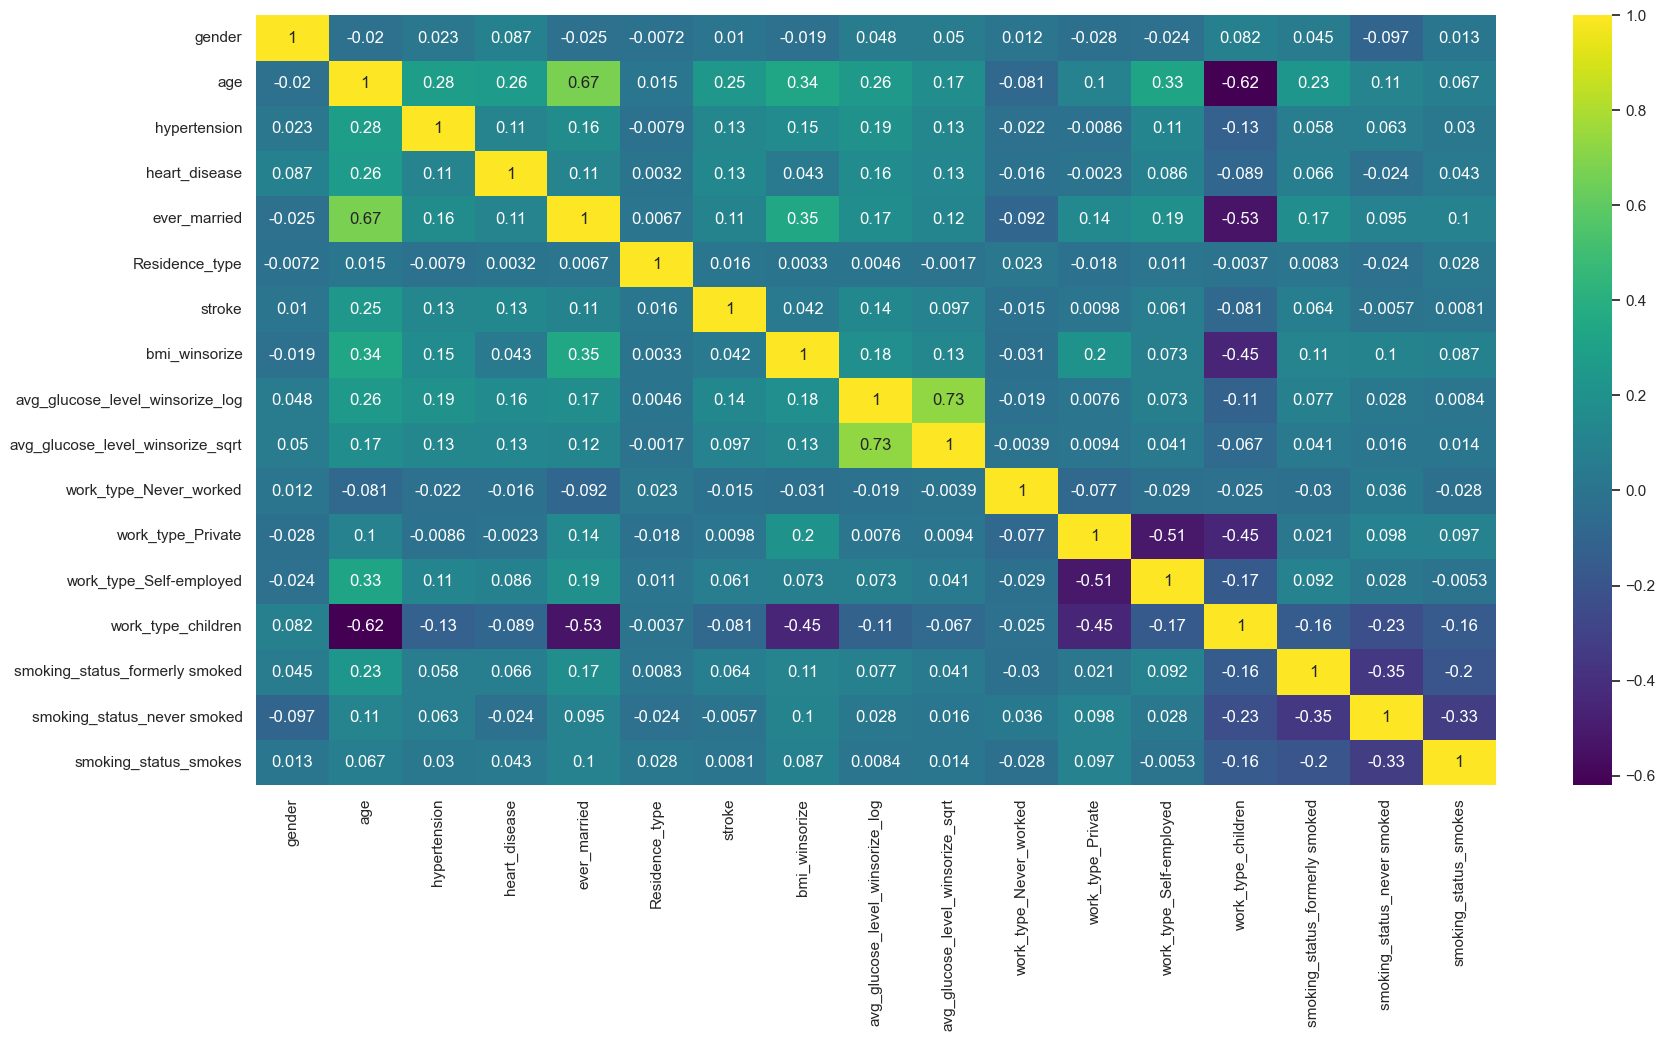

In [75]:
#checking for correlation
plt.figure(figsize=(20,10),dpi=100)
sns.heatmap(df_copy.corr(), annot=True, cmap='viridis')

## MODELLING

In [77]:
#Splitting my data
X=df_copy.drop(['stroke'], axis=1)
y=df_copy['stroke']

X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

X_test.shape , X_train.shape

((1014, 16), (4052, 16))

In [149]:

# Creating a dictionary of model
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVC": SVC(),
    "LGBM": LGBMClassifier(),
    "XGBOOST": XGBClassifier(),
    "CatBoost": CatBoostClassifier(),
    "NaiveBayes": GaussianNB()}

# Creating a function to make predictions using the trained models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Makes predictions using given machine learning models
    models: a dict of different sklearn machine learning models with hyperparameter grids
    X_train: training data
    X_test: testing data
    y_train: training labels
    """
    #set rabdom seed
    np.random.seed(42)
    #make a dictionary ro keep model score
    model_scores={}
    #loop through models
    for name,model in models.items():
        #fit the model to the data
        model.fit(X_train,y_train)
        #score the model
        model_scores[name]=model.score(X_test, y_test)
    return model_scores

In [89]:
model_scores=fit_and_score(models=models, X_train = X_train, X_test = X_test, y_train = y_train, y_test = y_test)
model_scores

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 187, number of negative: 3865
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 147
[LightGBM] [Info] Number of data points in the train set: 4052, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.046150 -> initscore=-3.028608
[LightGBM] [Info] Start training from score -3.028608
Learning rate set to 0.018724
0:	learn: 0.6652739	total: 6ms	remaining: 5.99s
1:	learn: 0.6412501	total: 9.58ms	remaining: 4.78s
2:	learn: 0.6168615	total: 12.4ms	remaining: 4.13s
3:	learn: 0.5935712	total: 17.4ms	remaining: 4.33s
4:	learn: 0.5659800	total: 21.7ms	remaining: 4.33s
5:	learn: 0.5417408	total: 25.8ms	remaining: 4.27s
6:	learn: 0.5197104	total: 29.3ms	

{'Logistic Regression': 0.9388560157790927,
 'KNN': 0.9378698224852071,
 'Random Forest': 0.9349112426035503,
 'Decision Tree': 0.8806706114398422,
 'SVC': 0.9388560157790927,
 'LGBM': 0.9339250493096647,
 'XGBOOST': 0.9299802761341223,
 'CatBoost': 0.9349112426035503,
 'NaiveBayes': 0.35404339250493094}

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVC": SVC(),
    "LGBM": LGBMClassifier(),
    "XGBOOST": XGBClassifier(),
    "CatBoost": CatBoostClassifier(),
    "NaiveBayes": GaussianNB()}

In [93]:
model_scores

{'Logistic Regression': 0.9388560157790927,
 'KNN': 0.9378698224852071,
 'Random Forest': 0.9349112426035503,
 'Decision Tree': 0.8806706114398422,
 'SVC': 0.9388560157790927,
 'LGBM': 0.9339250493096647,
 'XGBOOST': 0.9299802761341223,
 'CatBoost': 0.9349112426035503,
 'NaiveBayes': 0.35404339250493094}

In [134]:
scores=pd.DataFrame({'scores': model_scores}).sort_values('scores', ascending=False)

In [135]:
scores

,scores
Logistic Regression,0.938856
SVC,0.938856
KNN,0.937870
CatBoost,0.934911
Random Forest,0.934911
LGBM,0.933925
XGBOOST,0.929980
Decision Tree,0.880671
NaiveBayes,0.354043


In [136]:
my_dict={'Actual': y_test, 'Pred': y_pred}
compare = pd.DataFrame(my_dict)

In [214]:
compare.sample(1000, replace=True,random_state=4)

,Actual,Pred
29,1,0
4916,0,0
346,0,0
238,1,0
4450,0,0
...,...,...
673,0,0
1015,0,0
1425,0,0
1015,0,0


## HYPERPARAMETER GridSearchCV for Logistic Regression and SVC

In [166]:
#setting up hyperparameters for logistic model
params={'C': np.logspace(-4,4,30), 'penalty': ['l1','l2'], 'solver':['newton-cg','liblinear', 'sag','saga']}
#setup hyperparameter grid search
gs_log_reg = GridSearchCV(LogisticRegression(), param_grid=params,cv=10, verbose=True)

#fitting our model
gs_log_reg.fit(X_train,y_train)

Fitting 10 folds for each of 240 candidates, totalling 2400 fits


GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-04, 1.88739182e-04, 3.56224789e-04, 6.72335754e-04,
       1.26896100e-03, 2.39502662e-03, 4.52035366e-03, 8.53167852e-03,
       1.61026203e-02, 3.03919538e-02, 5.73615251e-02, 1.08263673e-01,
       2.04335972e-01, 3.85662042e-01, 7.27895384e-01, 1.37382380e+00,
       2.59294380e+00, 4.89390092e+00, 9.23670857e+00, 1.74332882e+01,
       3.29034456e+01, 6.21016942e+01, 1.17210230e+02, 2.21221629e+02,
       4.17531894e+02, 7.88046282e+02, 1.48735211e+03, 2.80721620e+03,
       5.29831691e+03, 1.00000000e+04]),
                         'penalty': ['l1', 'l2'],
                         'solver': ['newton-cg', 'liblinear', 'sag', 'saga']},
             verbose=True)

In [167]:
gs_log_reg.best_params_

{'C': 1.3738237958832638, 'penalty': 'l1', 'solver': 'saga'}

In [168]:
gs_log_reg.best_score_

0.954096576050599

In [169]:
gs_log_reg.score(X_test, y_test)

0.9388560157790927

In [170]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       952
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1014
   macro avg       0.47      0.50      0.48      1014
weighted avg       0.88      0.94      0.91      1014



In [171]:
clf=LogisticRegression(C=1.3738237958832638, penalty='l1', solver='saga')

In [172]:
clf.fit(X_train,y_train)

LogisticRegression(C=1.3738237958832638, penalty='l1', solver='saga')

In [174]:
y_preds=clf.predict(X_test)

In [191]:
accuracy_score(y_preds,y_test)

0.9388560157790927

In [189]:
cv_acc = cross_val_score(clf, X,y,cv=10, scoring='accuracy')
cv_acc


array([0.95069034, 0.95069034, 0.95069034, 0.95069034, 0.95069034,
       0.95069034, 0.95059289, 0.95059289, 0.95059289, 0.95256917])

In [177]:
cv_acc=np.mean(cv_acc)

In [178]:
cv_acc

0.9508489837921277

In [179]:
#setting up hyperparameters for svc model
params={'C': [0.1,1,10], 'gamma':[1,0.1,0.01],'kernel': ['poly','rbf']}

#setup hyperparameter grid search
svc_grid = GridSearchCV(SVC(), param_grid=params, cv=10, verbose=True)

#fitting our model
svc_grid.fit(X_train,y_train)

Fitting 10 folds for each of 18 candidates, totalling 180 fits


GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': [1, 0.1, 0.01],
                         'kernel': ['poly', 'rbf']},
             verbose=True)

In [180]:
svc_grid.best_params_

{'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}

In [186]:
svc=SVC(kernel='rbf', gamma=1, C=0.1)

In [187]:
svc.fit(X_train,y_train)

SVC(C=0.1, gamma=1)

In [192]:
y_pred2=svc.predict(X_test)

In [193]:
accuracy_score(y_pred2, y_test)

0.9388560157790927

Logistic Regression

In [213]:
my_dict={'Actual': y_test, 'Pred': y_preds}
compare = pd.DataFrame(my_dict)
compare.sample(1000, random_state=4,replace=True )

,Actual,Pred
29,1,0
4916,0,0
346,0,0
238,1,0
4450,0,0
...,...,...
673,0,0
1015,0,0
1425,0,0
1015,0,0


SVC

In [212]:
my_dict={'Actual': y_test, 'Pred': y_pred2}
compare = pd.DataFrame(my_dict)
compare.sample(1000, random_state=4, replace=True)

,Actual,Pred
29,1,0
4916,0,0
346,0,0
238,1,0
4450,0,0
...,...,...
673,0,0
1015,0,0
1425,0,0
1015,0,0
